In [1]:

import kagglehub
import pandas as  pd  
import os
import matplotlib.pyplot as plt
import numpy as np



/workspaces/Deep-Learning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = kagglehub.dataset_download("sukhmandeepsinghbrar/daily-delhi-climate")
df = pd.read_csv(os.path.join(path, "DailyDelhiClimate.csv"))
df = df[['date', 'meantemp']]
df.head()

,date,meantemp
0,2013-01-01,10.000000
1,2013-01-02,7.400000
2,2013-01-03,7.166667
3,2013-01-04,8.666667
4,2013-01-05,6.000000


In [3]:
df = df.head(300).iloc[::3]
df.shape

(100, 2)

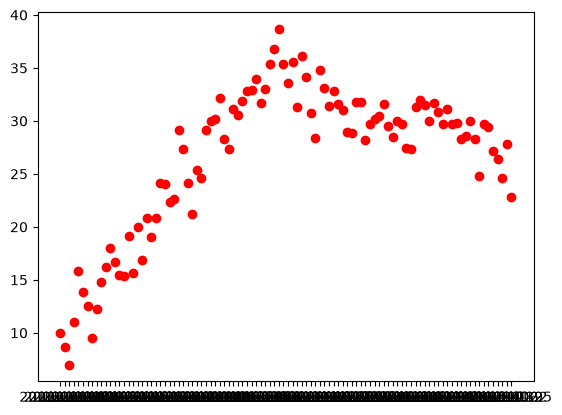

In [4]:
plt.scatter(df['date'], df['meantemp'],color='red')
plt.show()

<h1>Calculating EWMA (Exponentially Weighted Moving Average)</h1>
<br>
Calculating EWMA For various values of alpha i.e. for alpha = 0.9, 0.5, 0.1
EWMA is caluclated by the formula:
<p>S<sub>t</sub> = (1 - &alpha;)S<sub>t-1</sub> + &alpha;X<sub>t</sub> </p>
where
<ul>
    <li>X<sub>t</sub> = current temperature</li>
    <li>S<sub>t</sub> = current EWMA</li>
    <li>S<sub>t-1</sub> = previous EWMA</li>
    <li>&alpha; = smoothing factor</li>
</ul>

The value of α determines how much importance we give to the current observation.<br>
If α is large: The current observation receives more weight. EWMA reacts quickly to recent changes.<br>
If α is small: The previous EWMA receives more weight.EWMA changes slowly and produces a smoother curve.

In [5]:
df = df.reset_index(drop = True)
x=[]
for i in range(9,0,-1):
    df[f'ewma with alpha {i/10}']= df['meantemp'].ewm(alpha=i/10).mean()

#x1 = df['meantemp'].ewm(alpha=0.9).mean()
#df['ewma with alpha 0.9']= x1
#
#x2 = df['meantemp'].ewm(alpha=0.5).mean()
#df['ewma with alpha 0.5']= x2
#
#x3 = df['meantemp'].ewm(alpha=0.1).mean()
#df['ewma with alpha 0.1']= x3


df

,date,meantemp,ewma with alpha 0.9,ewma with alpha 0.8,ewma with alpha 0.7,ewma with alpha 0.6,ewma with alpha 0.5,ewma with alpha 0.4,ewma with alpha 0.3,ewma with alpha 0.2,ewma with alpha 0.1
0,2013-01-01,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
1,2013-01-04,8.666667,8.787879,8.888889,8.974359,9.047619,9.111111,9.166667,9.215686,9.259259,9.298246
2,2013-01-07,7.000000,7.177177,7.365591,7.553957,7.735043,7.904762,8.061224,8.203957,8.333333,8.450185
3,2013-01-10,11.000000,10.618062,10.277778,9.985886,9.745484,9.555556,9.411765,9.307804,9.236676,9.191625
4,2013-01-13,15.833333,15.311853,14.723645,14.089070,13.435984,12.795699,12.196970,11.660957,11.199032,10.813493
...,...,...,...,...,...,...,...,...,...,...,...
95,2013-10-13,27.166667,27.391194,27.597410,27.770304,27.905497,28.010605,28.109418,28.252616,28.534760,29.147573
96,2013-10-16,26.428571,26.524834,26.662339,26.831091,27.019342,27.219588,27.437080,27.705403,28.113522,28.875663
97,2013-10-19,24.571429,24.766769,24.989611,25.249327,25.550594,25.895508,26.290819,26.765210,27.405104,28.445225
98,2013-10-22,27.800000,27.496677,27.237922,27.034798,26.900238,26.847754,26.894491,27.075647,27.484083,28.380701


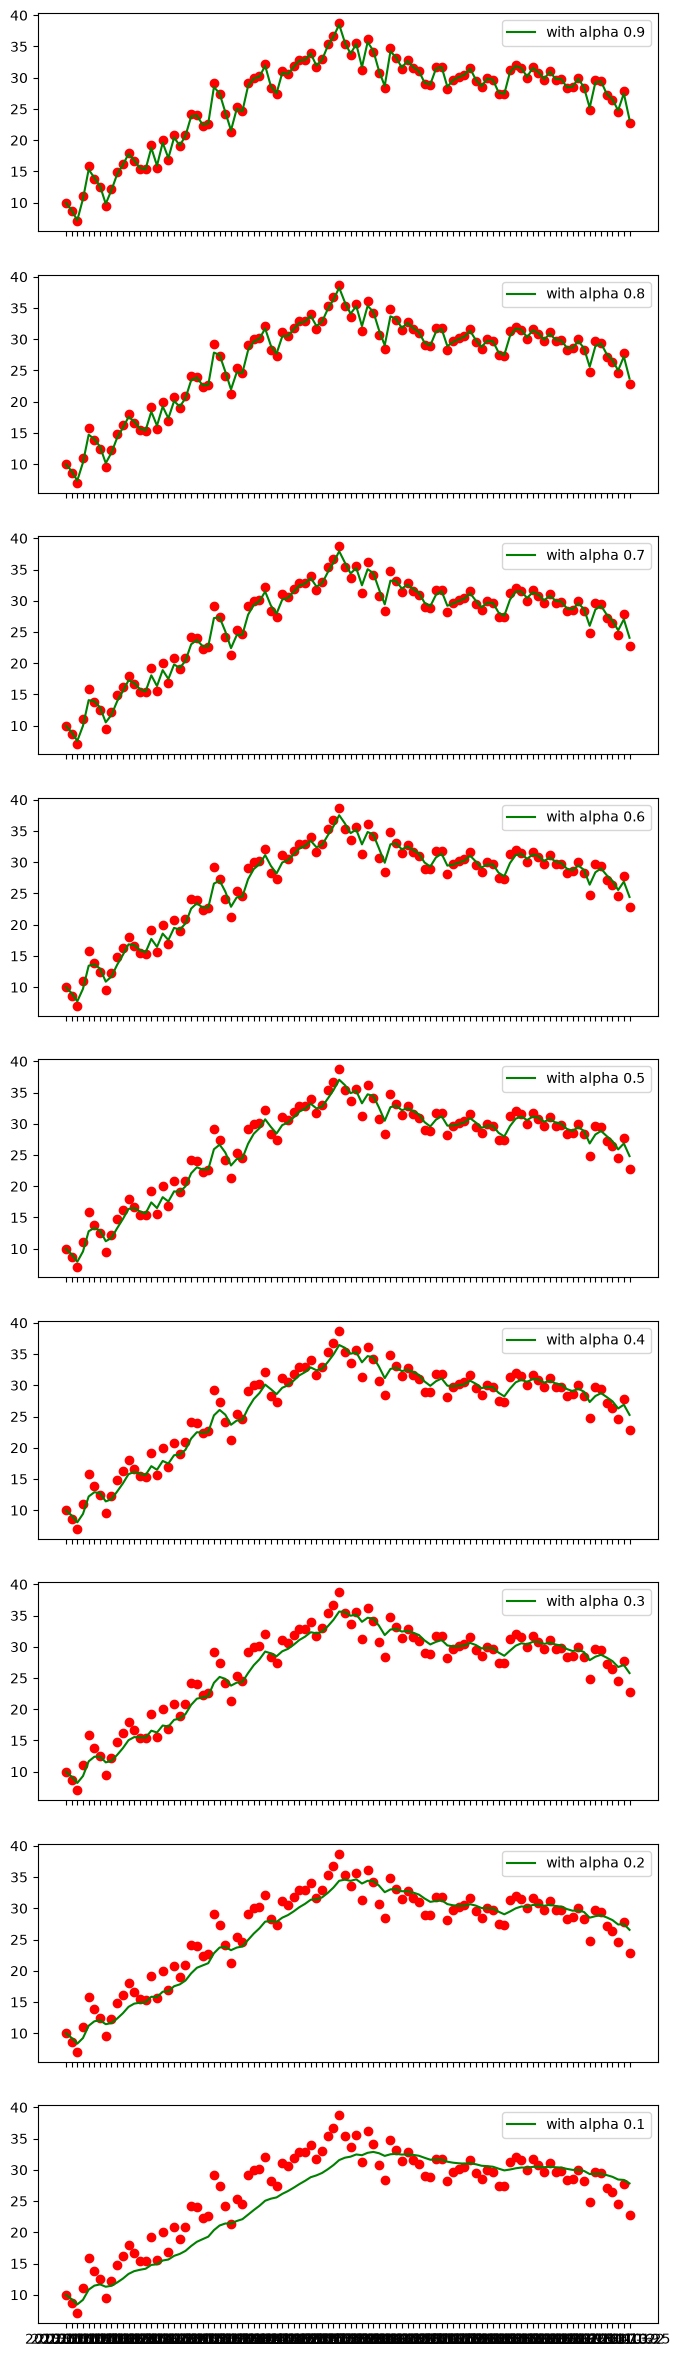

In [6]:
fig, ax = plt.subplots(9, 1, figsize=(8, 30), sharex=True)
for i in range(9,0,-1):
    ax[9-i].scatter(df['date'], df['meantemp'], color = 'red')
    ax[9-i].plot(df['date'],df[f'ewma with alpha {i/10}'], color = 'green', label = f'with alpha {i/10}')
    ax[9-i].legend()

#ax[0].scatter(df['date'], df['meantemp'], color = 'red')
#ax[0].plot(df['date'],x1, color = 'purple', label = 'with alpha 0.9')
#ax[0].legend()
#ax[1].scatter(df['date'], df['meantemp'], color = 'red')
#ax[1].plot(df['date'],x2, color = 'green', label = 'with alpha 0.5')
#ax[1].legend()
#ax[2].scatter(df['date'], df['meantemp'], color = 'red')
#ax[2].plot(df['date'],x3, color = 'blue', label = 'with alpha 0.1')
#ax[2].legend()
plt.show()

<h1>My Dataset</h1>
Making a non-convex loss surface on which we can test and visualize the results of optimizers

In [7]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(42)
tf.random.set_seed(42)

I0000 00:00:1789968609.070065    2457 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789968632.480997    2457 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789968645.153962    2457 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Our loss function is : L = (w<sub>1</sub><sup>2</sup> + w<sub>2</sub> - 11)<sup>2</sup> + (w<sub>1</sub> + w<sub>2</sub><sup>2</sup> - 7)<sup>2</sup> + 0.15(sin(3w<sub>1</sub>) * sin(3w<sub>2</sub>))

In [ ]:
A = 200.0                                   # curvature ratio: w1 direction is 200x steeper than w2
 
def loss_function(w1, w2):
    return 0.5 * (A * w1**2 + w2**2)        # long narrow valley, minimum at (0, 0)
 
START_W1, START_W2 = 1.0, 1.0
LEARNING_RATE = 0.02                        # same lr for ALL optimizers
EPOCHS = 300
 
# grid for the contour / 3D plots (replace your -5..5 grid with this one)
w1_range = np.linspace(-1.2, 1.2, 400)
w2_range = np.linspace(-1.2, 1.2, 400)
W1, W2 = np.meshgrid(w1_range, w2_range)
Z = 0.5 * (A * W1**2 + W2**2)


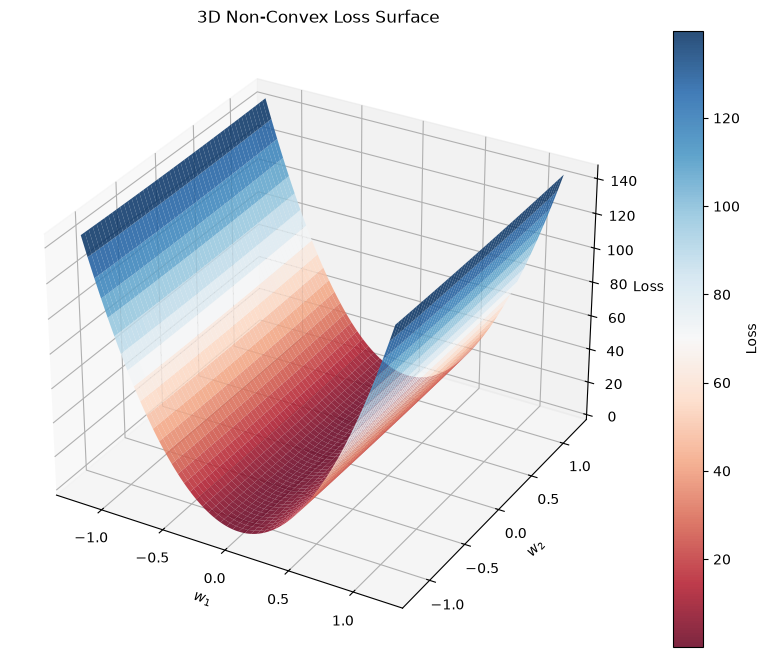

In [9]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

surface = ax.plot_surface(W1, W2, Z, cmap = "RdBu", alpha=0.85)

ax.set_xlabel("$w_1$")
ax.set_ylabel("$w_2$")
ax.set_zlabel("Loss")

ax.set_title("3D Non-Convex Loss Surface")

fig.colorbar(surface, ax=ax, label="Loss")

plt.show()

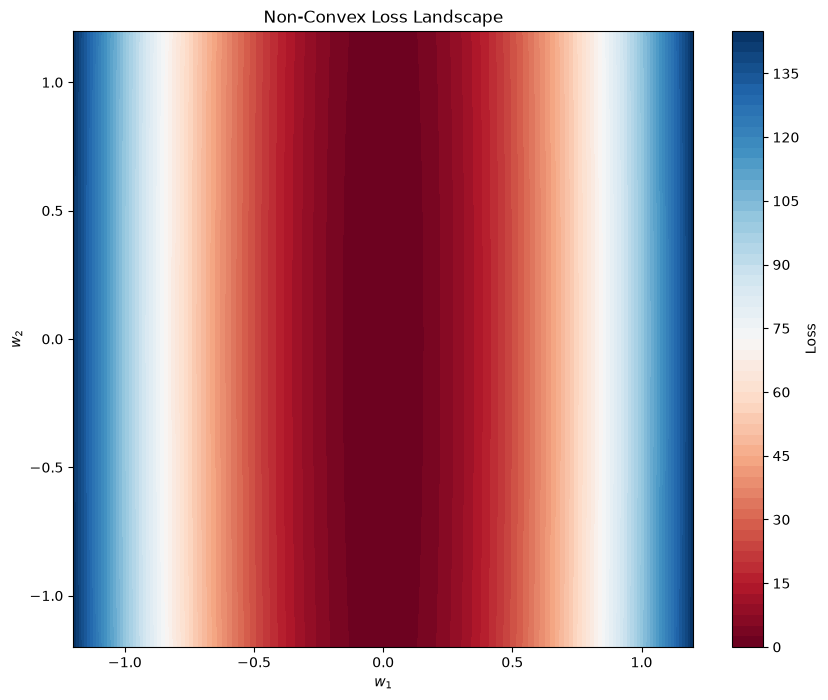

In [10]:
plt.figure(figsize=(10, 8))

contour = plt.contourf(W1, W2, Z, levels=60, cmap="RdBu")

plt.colorbar(contour, label="Loss")

plt.xlabel("$w_1$")
plt.ylabel("$w_2$")

plt.title("Non-Convex Loss Landscape")

plt.show()

<h1>Utility Setup</h1>
Setting up functions to run our optimizers and visualize the imporvements made

<h3>The Optimizer Runner Function</h3>

In [11]:
def run_optimizer(optimizer):
    w1 = tf.Variable(START_W1, dtype = tf.float32)
    w2 = tf.Variable(START_W2, dtype = tf.float32)

    trajectory_w1 = []
    trajectory_w2 = []
    trajectory_loss = []

    for i in range(300):
        trajectory_w1.append(w1.numpy())
        trajectory_w2.append(w2.numpy())

        with tf.GradientTape() as tape:
            loss = loss_function(w1, w2)

        gradients = tape.gradient(loss, [w1, w2])
        optimizer.apply_gradients(zip(gradients, [w1, w2]))

        trajectory_loss.append(loss.numpy())
    return {
        "w1": np.array(trajectory_w1),
        "w2": np.array(trajectory_w2),
        "loss": np.array(trajectory_loss)
    }


<h3>The Visualization Function</h3>

In [12]:
def visualize_Lossvsepoch(results, optimizer_name, ax=None):
    loss_path = results["loss"]
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(loss_path, linewidth=2)
    ax.set_xlabel("Epochs")
    ax.set_ylabel("Loss")
    ax.set_title(f"{optimizer_name} - Loss Vs Epoch Graph")
    ax.grid(alpha=0.3)

    return plt if standalone else ax


def visualize_contour(results, optimizer_name, ax=None):
    w1_path = results["w1"]
    w2_path = results["w2"]
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(10, 8))

    contour = ax.contourf(W1, W2, Z, levels=60, cmap="viridis")
    ax.plot(w1_path, w2_path, color="red", linewidth=2, label=optimizer_name)
    ax.scatter(w1_path[0], w2_path[0], color="white", s=120, label="start")
    ax.scatter(w1_path[-1], w2_path[-1], color="yellow", s=120, label="Final", marker="*")
    ax.set_xlabel("$w_1$")
    ax.set_ylabel("$w_2$")
    ax.set_title(f"{optimizer_name} - Optimization Trajectory")
    ax.legend()

    return plt if standalone else ax


def visualize_3dsurface(results, optimizer_name, ax=None):
    w1_path = results["w1"]
    w2_path = results["w2"]
    loss_path = results["loss"]
    standalone = ax is None
    if standalone:
        fig = plt.figure(figsize=(12, 9))
        ax = fig.add_subplot(111, projection="3d")

    ax.plot_surface(W1, W2, Z, cmap="viridis", alpha=0.85)
    ax.plot(w1_path, w2_path, loss_path, color="red", linewidth=3, label=optimizer_name)
    ax.scatter(w1_path[0], w2_path[0], loss_path[0], color="black", s=100)
    ax.scatter(w1_path[-1], w2_path[-1], loss_path[-1], color="yellow", s=150, marker="*")
    ax.set_xlabel("$w_1$")
    ax.set_ylabel("$w_2$")
    ax.set_zlabel("Loss")
    ax.set_title(f"{optimizer_name} - 3D Optimization Trajectory")

    return plt if standalone else ax

<h3>Animation Functions</h3>
a) Animation in 3D

In [13]:
from IPython.display import display, HTML
from matplotlib.animation import FuncAnimation

def animate_3d( results, optimizer_name, interval = 50, step = 3):
    w1_path = results["w1"]
    w2_path = results["w2"]
    loss_path = results["loss"]

    fig = plt.figure(figsize=(12,9))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(W1, W2, Z, cmap = "viridis", alpha = 0.85)

    trajectory_line, = ax.plot([], [], [], color = "red", linewidth = 3)
    point, = ax.plot([], [], [], "ro", markersize = 8)

    ax.set_xlabel("$w_1$")
    ax.set_ylabel("$w_2$")
    ax.set_zlabel("Loss")

    def init():
        trajectory_line.set_data([], [])
        trajectory_line.set_3d_properties([])
        point.set_data([], [])
        point.set_3d_properties([])

        return trajectory_line, point

    def update(frame):
        x = np.asarray(w1_path[:frame + 1])
        y = np.asarray(w2_path[:frame + 1])
        z = np.asarray(loss_path[:frame + 1])

        trajectory_line.set_data(x, y)
        trajectory_line.set_3d_properties(z)
        point.set_data([w1_path[frame]], [w2_path[frame]])
        point.set_3d_properties(loss_path[frame])

        ax.set_title(
            f"{optimizer_name} — Epoch {frame}\n"
            f"Loss = {loss_path[frame]:.4f}"
        )
        return trajectory_line, point

    frames = range(0, len(w1_path), step)

    animation = FuncAnimation( fig, update, frames = frames, init_func=init, interval = interval, blit = False, repeat = False)  

    plt.close(fig)
    return HTML(animation.to_jshtml())


b)Animation in Contour

In [14]:
def animate_contour(results, optimizer_name, interval = 50, step = 3):
    w1_path = results["w1"]
    w2_path = results["w2"]
    loss_path = results["loss"]

    fig= plt.figure(figsize = (10,8))
    contour = plt.contourf(W1, W2, Z, levels = 30, cmap = "viridis")
    fig.colorbar(contour, label = "Loss")

    trajectory_line, = plt.plot([], [], color = "red", linewidth = 3)
    point, = plt.plot([], [], "ro", markersize = 8)

    plt.scatter(w1_path[0], w2_path[0], color="white", s=100, label="Start")
    plt.xlabel("$w_1$")
    plt.ylabel("$w_2$")
    plt.title(f"{optimizer_name} — Optimization Progress")
    plt.legend()

    def init():
        trajectory_line.set_data([], [])
        point.set_data([], [])

        return trajectory_line, point

    def update(frame):
        trajectory_line.set_data(np.asarray(w1_path[:frame + 1]),np.asarray(w2_path[:frame + 1]))
        point.set_data([w1_path[frame]],[w2_path[frame]])

        ax.set_title(f"{optimizer_name} — Epoch {frame}\n" f"Loss = {loss_path[frame]:.4f}")
        return trajectory_line, point

    frames = range(0, len(w1_path), step)
    animation = FuncAnimation( fig, update, frames = frames, init_func = init, interval = interval, blit = True, repeat = False)

    plt.close(fig)
    return HTML(animation.to_jshtml())

<h1>Vanilla Gradient Descent</h1>
It uses gradient directly for updating parameters<br>
W<sub>t</sub> = W<sub>t-1</sub> - &eta; &Delta; L<sub>t</sub><br>


In [15]:
sgd_optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)
sgd_results = run_optimizer(sgd_optimizer)

E0000 00:00:1789968656.109741    2457 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


<h1>SGD with Momentum</h1>
It uses velocity for updating rather than using gradient directly<br>
W<sub>t</sub> = W<sub>t-1</sub> - &eta; v<sub>t</sub><br>
The velocity is update depends on previous velocity and current gradient<br>
v<sub>t</sub> = &beta; v<sub>t-1</sub> + (1 - &beta;) &Delta;L<sub>t</sub>



In [16]:
momentum_optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
momentum_results = run_optimizer(momentum_optimizer)

<h1>Nesterov Accelerated Gradient (NAG)</h1>
This also uses velocity for updating but with a littele twist from that before:<br>
W<sub>t</sub> = W<sub>t-1</sub> - &eta; v<sub>t</sub><br>
Rather than using gradient of current point in calulation of velocity, <br>
It First calculates where the momentum would take you in form of look ahead<br>
W<sub>la</sub> = W<sub>t-1</sub> - &eta;&beta;v<sub>t-1</sub><br>
And then uses that look ahead point's gradient in the calcualtion of velocity<br>
v<sub>t</sub> = &beta; v<sub>t-1</sub> + &eta;&Delta;L<sub>t</sub>(W<sub>la</sub>)


In [17]:
nesterov_optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov = True)
nesterov_results = run_optimizer(nesterov_optimizer)

<h1>AdaGrad (Adaptive Gradient)</h1>
In this optimizer different paramters have different learning ratesbased on their acumulated squared gradients<br>


In [18]:
adagrad_optimizer = tf.keras.optimizers.Adagrad(learning_rate = 0.01)
adagrad_results = run_optimizer(adagrad_optimizer)

<h1>RMS Prop( Root Mean Square Propagation)</h1>

In [19]:
rmsprop_optimizer = tf.keras.optimizers.RMSprop(learning_rate = 0.01, rho = 0.9)
rmsprop_results = run_optimizer(rmsprop_optimizer)

<h1>Adam (Adaptive Momement Estimation)</h1>

In [20]:
adam_optimizer = tf.keras.optimizers.Adam(learning_rate = 0.01, beta_1 = 0.9, beta_2 = 0.999)
adam_results = run_optimizer(adam_optimizer)

<h1>Visualization of Loss Vs Epoch Graph</h1>

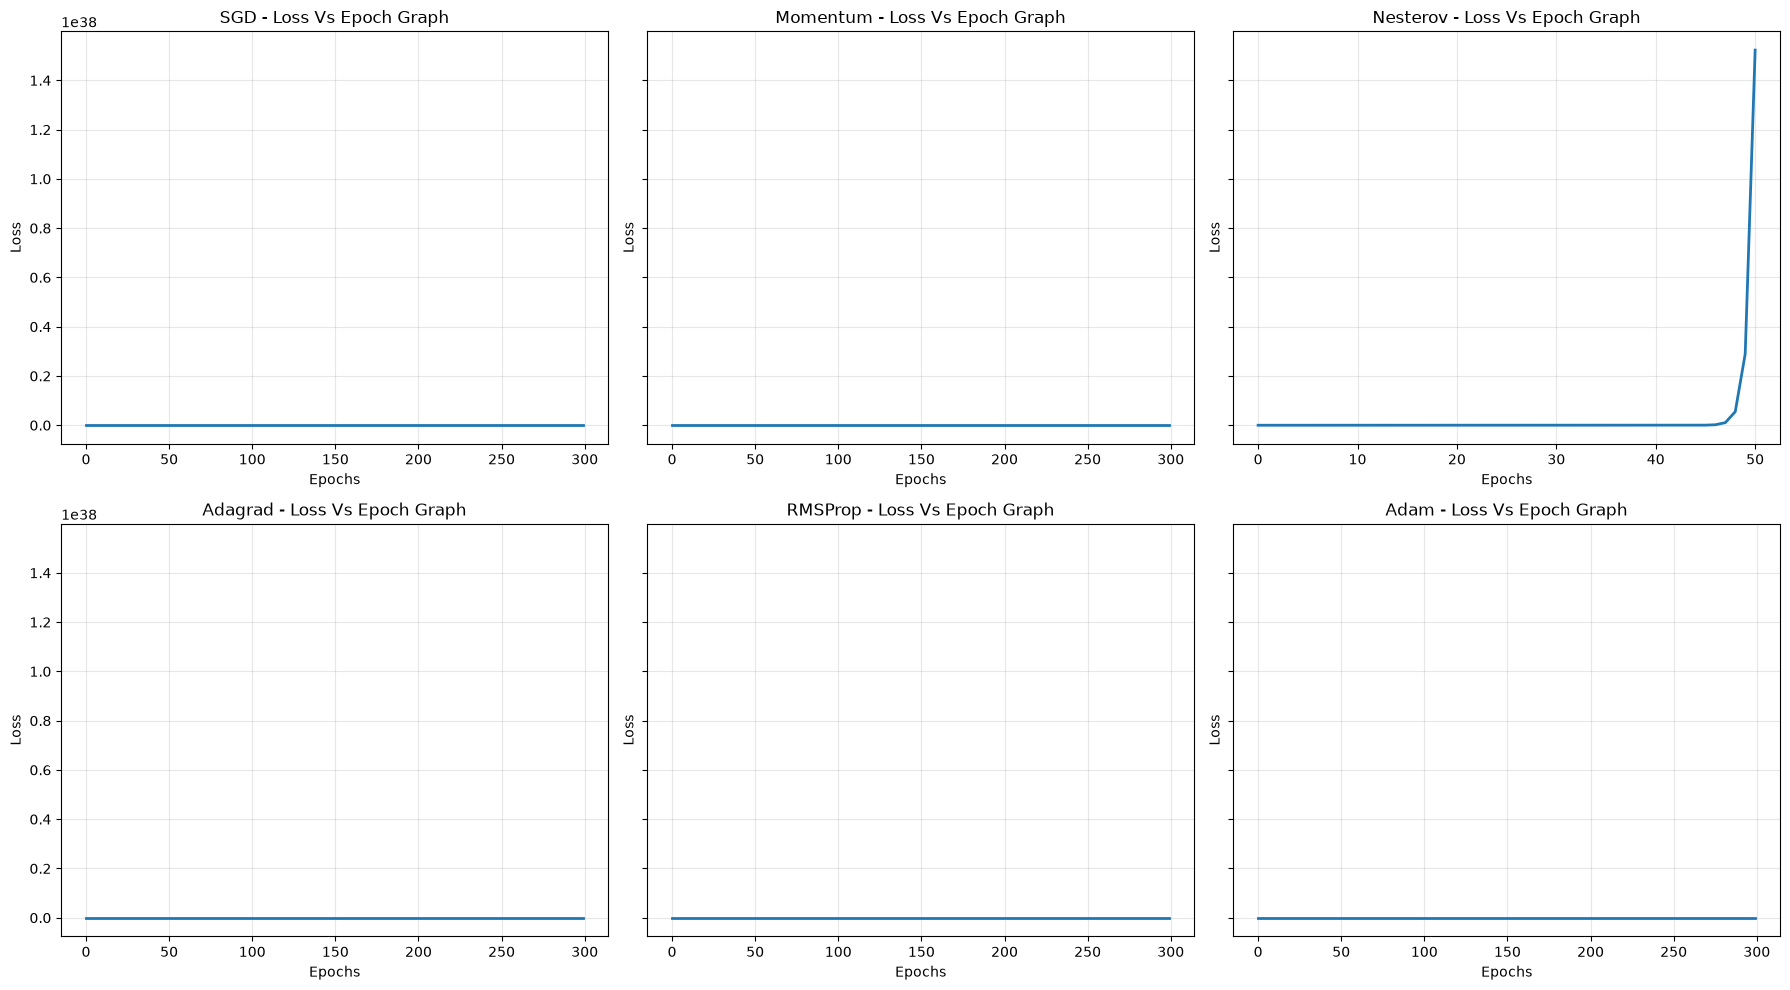

In [21]:
all_results = {
    "SGD": sgd_results,
    "Momentum": momentum_results,
    "Nesterov": nesterov_results,
    "Adagrad": adagrad_results,
    "RMSProp": rmsprop_results,
    "Adam": adam_results,
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
axes = axes.flatten()  # turns 2x3 grid into a flat list of 6 for easy zipping

for ax, (name, res) in zip(axes, all_results.items()):
    visualize_Lossvsepoch(res, name, ax=ax)

plt.tight_layout()
plt.show()

<h1>Updates in parameters in 3D Loss Surface</h1>

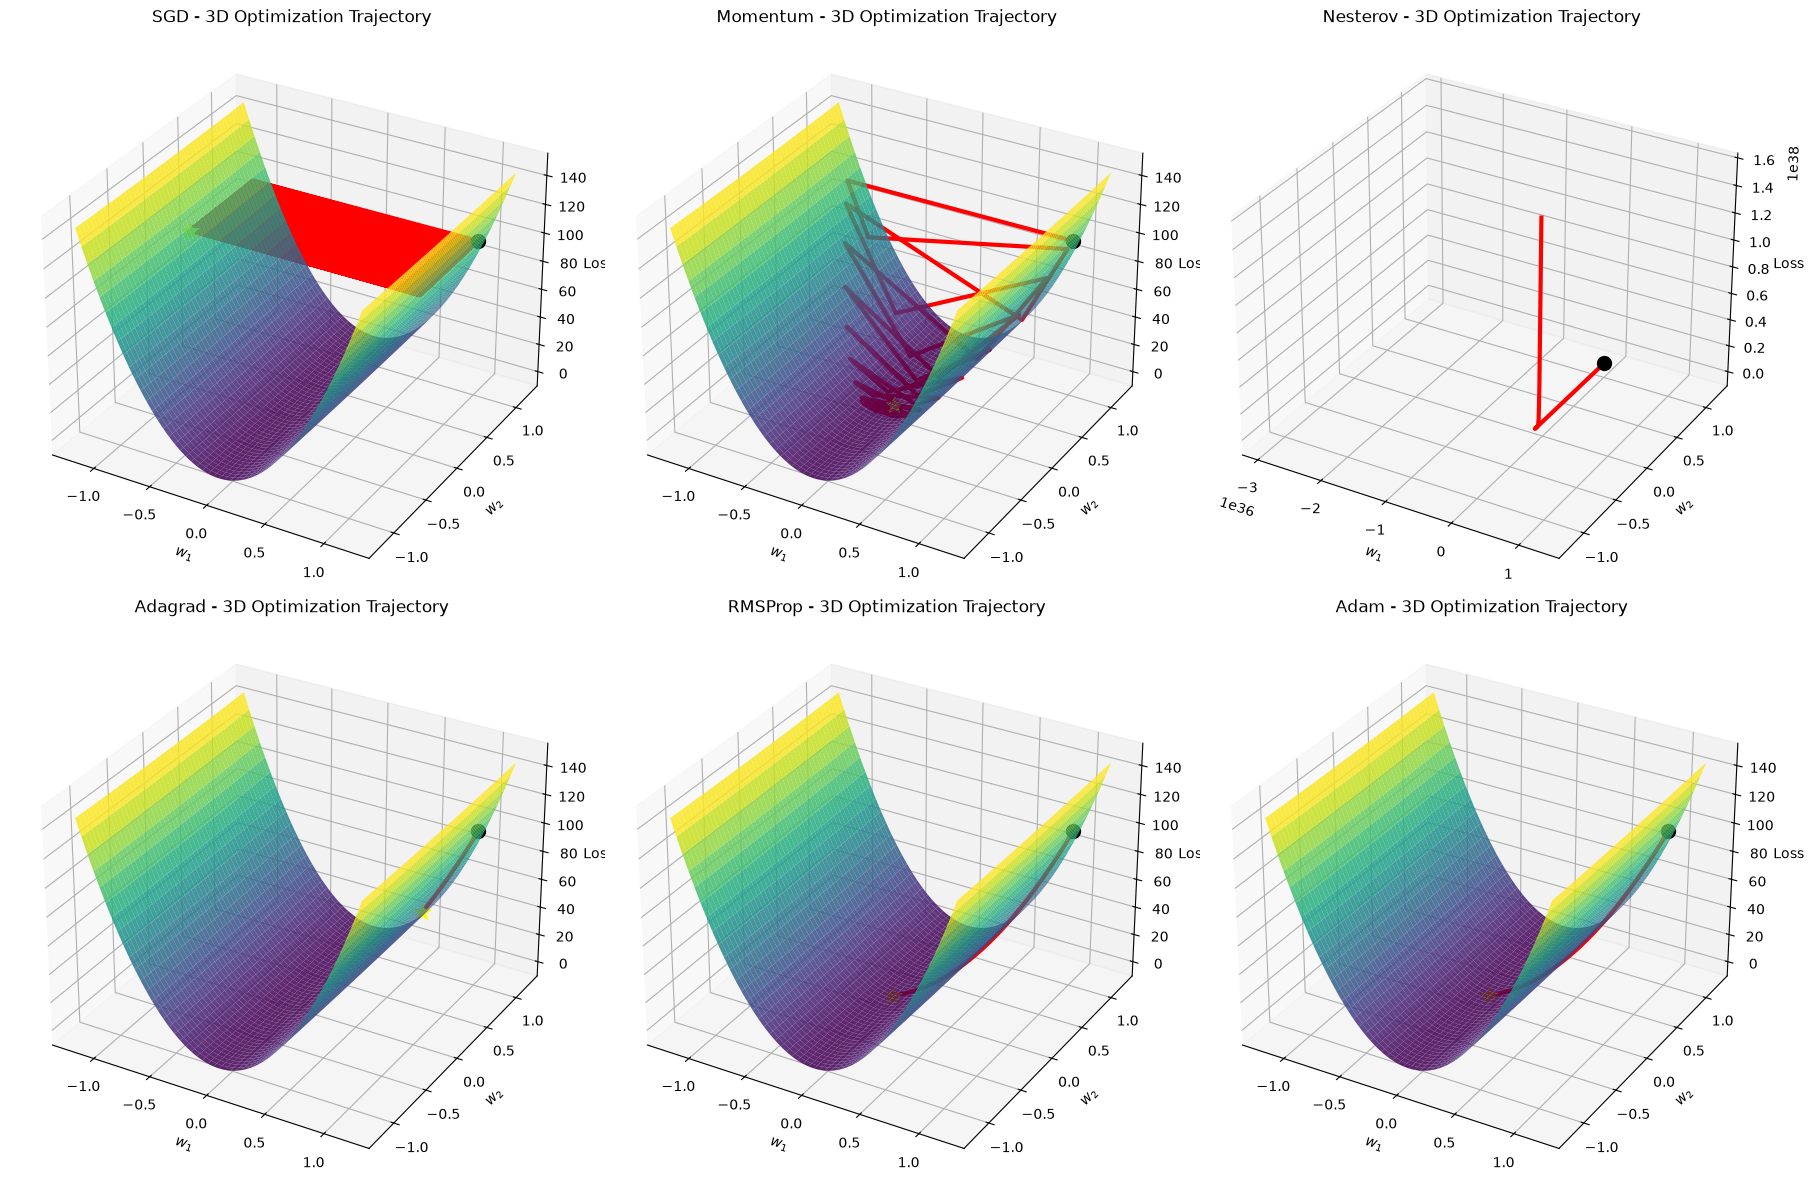

In [22]:
fig = plt.figure(figsize=(18, 12))
for i, (name, res) in enumerate(all_results.items()):
    ax = fig.add_subplot(2, 3, i + 1, projection="3d")
    visualize_3dsurface(res, name, ax=ax)

plt.tight_layout()
plt.show()

<h1>Updates in parameters in Countour</h1>

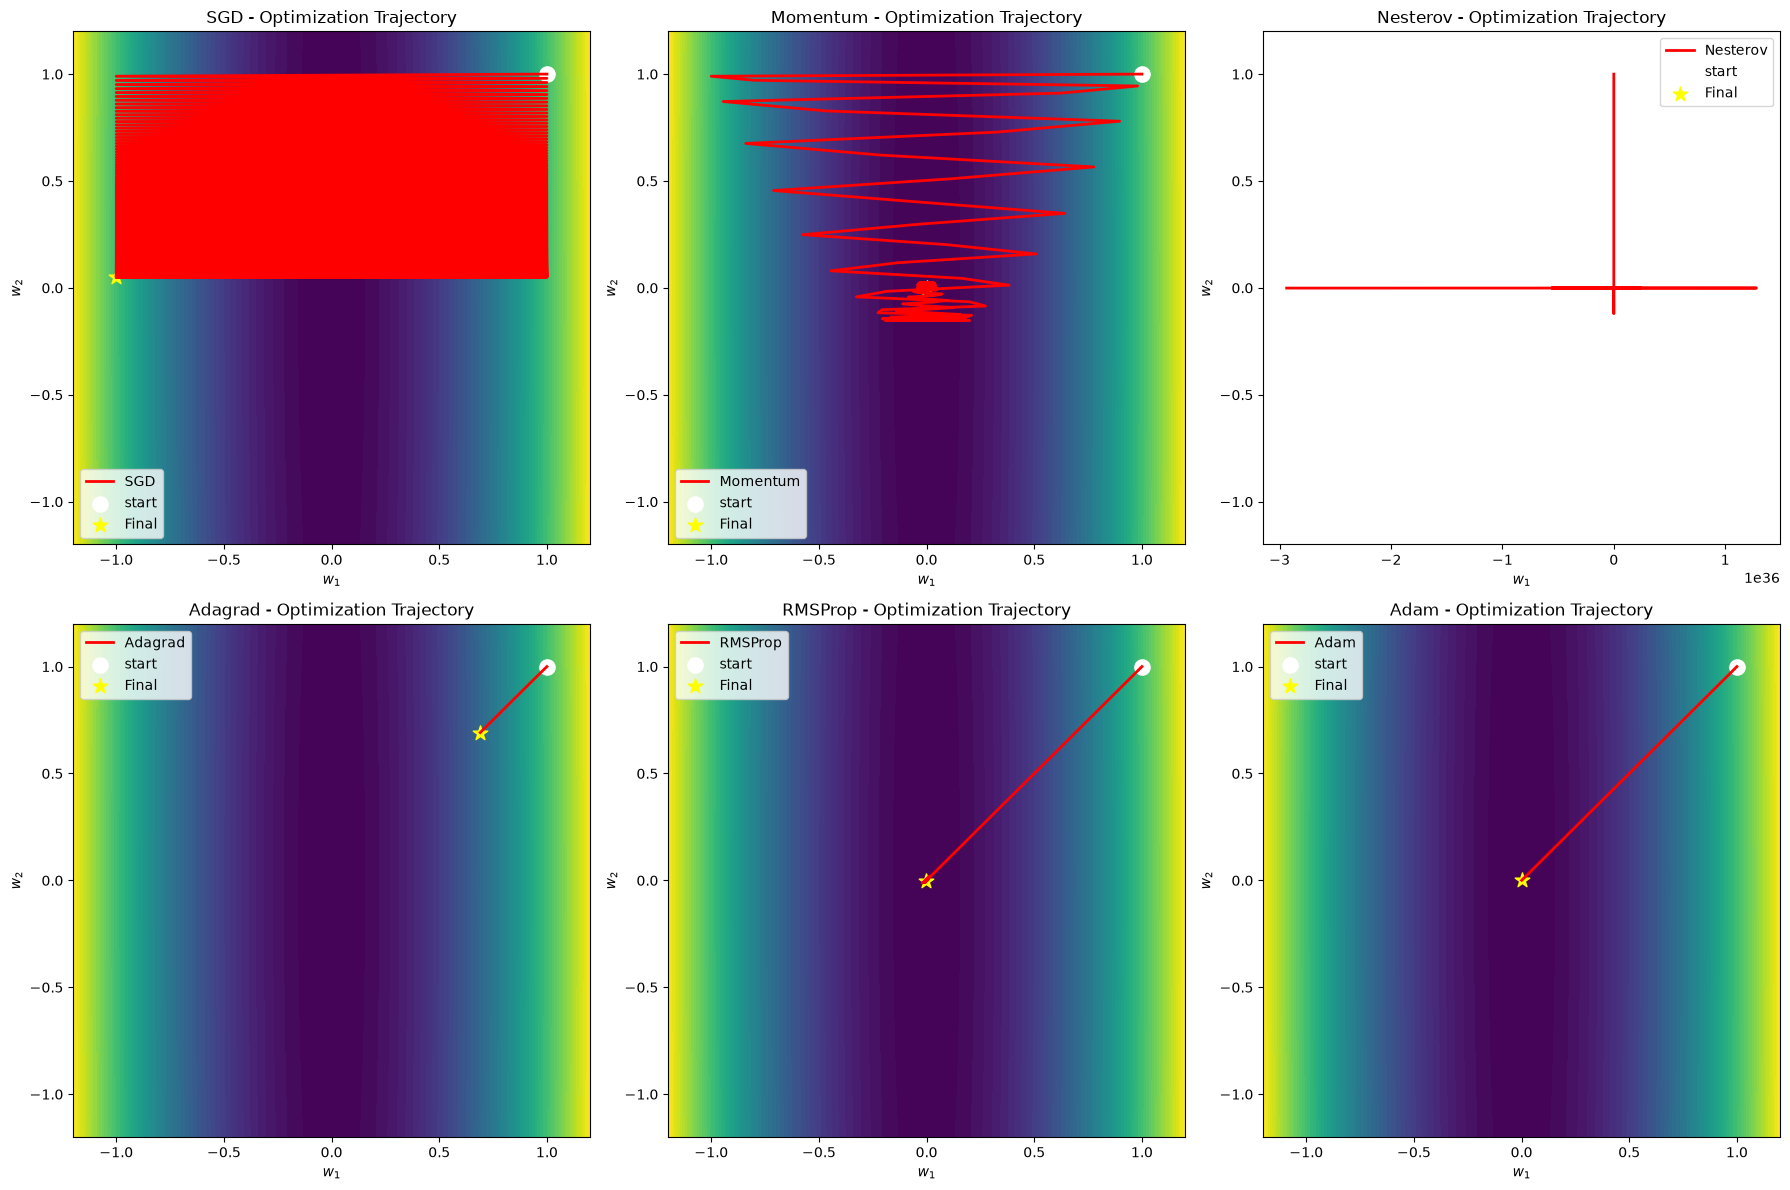

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, (name, res) in zip(axes, all_results.items()):
    visualize_contour(res, name, ax=ax)

plt.tight_layout()
plt.show()

<h1>Defining A common animation function for seeing updates in sync</h1>

In [24]:
def animate_3d_combined(all_results, interval=50, step=3, nrows=2, ncols=3):
    names = list(all_results.keys())
    n = len(names)

    fig = plt.figure(figsize=(6 * ncols, 6 * nrows))
    axes = []
    lines = []
    points = []

    max_len = max(len(res["w1"]) for res in all_results.values())

    for i, name in enumerate(names):
        ax = fig.add_subplot(nrows, ncols, i + 1, projection="3d")
        ax.plot_surface(W1, W2, Z, cmap="viridis", alpha=0.5)
        ax.set_xlabel("$w_1$")
        ax.set_ylabel("$w_2$")
        ax.set_zlabel("Loss")
        ax.set_title(name)

        line, = ax.plot([], [], [], color="red", linewidth=3)
        point, = ax.plot([], [], [], "ro", markersize=8)

        axes.append(ax)
        lines.append(line)
        points.append(point)

    def init():
        for line, point in zip(lines, points):
            line.set_data([], [])
            line.set_3d_properties([])
            point.set_data([], [])
            point.set_3d_properties([])
        return lines + points

    def update(frame):
        for ax, line, point, name in zip(axes, lines, points, names):
            res = all_results[name]
            w1_path, w2_path, loss_path = res["w1"], res["w2"], res["loss"]

            f = min(frame, len(w1_path) - 1)
            x = np.asarray(w1_path[:f + 1])
            y = np.asarray(w2_path[:f + 1])
            z = np.asarray(loss_path[:f + 1])

            line.set_data(x, y)
            line.set_3d_properties(z)
            point.set_data(np.array([w1_path[frame]]), np.array([w2_path[frame]]))
            point.set_3d_properties(np.array([loss_path[frame]]))

            ax.set_title(f"{name}\nEpoch {f}, Loss={loss_path[f]:.4f}")
        return lines + points

    frames = range(0, max_len, step)
    animation = FuncAnimation(fig, update, frames=frames, init_func=init,
                               interval=interval, blit=False, repeat=False)
    plt.tight_layout()
    plt.close(fig)
    return HTML(animation.to_jshtml())


def animate_contour_combined(all_results, interval=50, step=3, nrows=2, ncols=3):
    names = list(all_results.keys())
    n = len(names)

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 6 * nrows))
    axes = axes.flatten()

    lines = []
    points = []
    max_len = max(len(res["w1"]) for res in all_results.values())

    for ax, name in zip(axes, names):
        res = all_results[name]
        contour = ax.contourf(W1, W2, Z, levels=30, cmap="viridis")
        ax.scatter(res["w1"][0], res["w2"][0], color="white", s=100, label="Start")
        ax.set_xlabel("$w_1$")
        ax.set_ylabel("$w_2$")
        ax.set_title(name)
        ax.legend()

        line, = ax.plot([], [], color="red", linewidth=3)
        point, = ax.plot([], [], "ro", markersize=8)
        lines.append(line)
        points.append(point)

    # hide any unused axes (e.g. if you pass fewer than nrows*ncols results)
    for ax in axes[n:]:
        ax.axis("off")

    fig.colorbar(contour, ax=axes[:n], label="Loss", fraction=0.02, pad=0.02)

    def init():
        for line, point in zip(lines, points):
            line.set_data([], [])
            point.set_data([], [])
        return lines + points

    def update(frame):
        for ax, line, point, name in zip(axes, lines, points, names):
            res = all_results[name]
            w1_path, w2_path, loss_path = res["w1"], res["w2"], res["loss"]

            f = min(frame, len(w1_path) - 1)
            line.set_data(np.asarray(w1_path[:f + 1]), np.asarray(w2_path[:f + 1]))
            point.set_data([w1_path[f]], [w2_path[f]])
            ax.set_title(f"{name} — Epoch {f}, Loss={loss_path[f]:.4f}")
        return lines + points

    frames = range(0, max_len, step)
    animation = FuncAnimation(fig, update, frames=frames, init_func=init,
                               interval=interval, blit=False, repeat=False)
    plt.tight_layout()
    plt.close(fig)
    return HTML(animation.to_jshtml())

<h1>Animated updates in Contour</h1>

In [ ]:
animate_contour_combined(all_results, step=3)

<h1>Animated updates in 3D Loss Surface</h1>

In [ ]:
animate_3d_combined(all_results, step=3)